In [1]:
import sys
!{sys.executable} -m pip install imageio
import imageio


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
#import necessary libraries when needed
import os
import numpy as np
import pandas as pd
import pathlib
import imageio



# You can write up to 5GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

**<font size="3">Now , We jump to get insight of the dataset.
Dataset has three folders (train , val ,test).</font>**


In [3]:
# Exploring dataset 
base_dir = 'C:/Users/spiri/Downloads/Chest x-ray/chest_xray/'

train_pneumonia_dir = base_dir+'train/PNEUMONIA/'
train_normal_dir=base_dir+'train/NORMAL/'

test_pneumonia_dir = base_dir+'test/PNEUMONIA/'
test_normal_dir = base_dir+'test/NORMAL/'

val_normal_dir= base_dir+'val/NORMAL/'
val_pnrumonia_dir= base_dir+'val/PNEUMONIA/'

train_pn = [train_pneumonia_dir+"{}".format(i) for i in os.listdir(train_pneumonia_dir) ]
train_normal = [train_normal_dir+"{}".format(i) for i in os.listdir(train_normal_dir) ]

test_normal = [test_normal_dir+"{}".format(i) for i in os.listdir(test_normal_dir)]
test_pn = [test_pneumonia_dir+"{}".format(i) for i in os.listdir(test_pneumonia_dir)]

val_pn= [val_pnrumonia_dir+"{}".format(i) for i in os.listdir(val_pnrumonia_dir) ]
val_normal= [val_normal_dir+"{}".format(i) for i in os.listdir(val_normal_dir) ]

print ("Total images:",len(train_pn+train_normal+test_normal+test_pn+val_pn+val_normal))
print ("Total pneumonia images:",len(train_pn+test_pn+val_pn))
print ("Total Nomral images:",len(train_normal+test_normal+val_normal))


Total images: 5856
Total pneumonia images: 4273
Total Nomral images: 1583


## Dataset Preprocessing & Visualization ## 
**<font size="3">The dataset is small. So, We follow 80%, 15%, 5% split. Besides, dataset is clearly imbalanced. We will take care of it later. </font>**

In [4]:
# Dataset Splitting (train 80% , test 15% and validation 5% )

# Gathering all pneumina and normal chest X-ray in two python list
pn = train_pn + test_pn + val_pn
normal = train_normal + test_normal + val_normal

# Spliting dataset in train set,test set and validation set.

train_imgs = pn[:3418]+ normal[:1224]  # 80% of 4273 Pneumonia and normal chest X-ray are 3418 and 1224 respectively.
test_imgs = pn[3418:4059]+ normal[1224:1502]
val_imgs = pn[4059:] + normal[1502:]

print("Total Train Images %s containing %s pneumonia and %s normal images" 
      % (len(train_imgs),len(pn[:3418]),len(normal[:1224])))
print("Total Test Images %s containing %s pneumonia and %s normal images"
      % (len(test_imgs),len(pn[3418:4059]),len(normal[1224:1502])))
print("Total validation Images %s containing %s pneumonia and %s normal images" 
      % (len(val_imgs),len(pn[4059:]),len(normal[1502:])))



import random

random.shuffle(train_imgs)
random.shuffle(test_imgs)
random.shuffle(val_imgs)

Total Train Images 4642 containing 3418 pneumonia and 1224 normal images
Total Test Images 919 containing 641 pneumonia and 278 normal images
Total validation Images 295 containing 214 pneumonia and 81 normal images


In [5]:
#showing a file name from test set
print(test_imgs[5])

C:/Users/spiri/Downloads/Chest x-ray/chest_xray/test/PNEUMONIA/person122_bacteria_584.jpeg


**<font size="3">Loading each image and their label into array</font>**

In [6]:
import cv2
img_size = 224

def preprocess_image(image_list):
    
    X = [] # images
    y = [] #labels (0 for Normal or 1 for Pneumonia)
    count=0
    
    for image in image_list:
        
        try:

            img = cv2.imread(image,cv2.IMREAD_GRAYSCALE)
            
            img=cv2.resize(img,(img_size,img_size),interpolation=cv2.INTER_CUBIC)
            
            #convert image to 2D to 3D 
            img = np.dstack([img, img, img])
            
            #convrt greyscale image to RGB
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            
            # Normalalize Image
            img = img.astype(np.float32)/255.
            
            count=count+1

            X.append(img) 
            
            
        except:
            continue
        #get the labels 
        if 'NORMAL' in image:
            y.append(0)
            
        elif 'IM' in image:
            y.append(0)
            
        elif 'virus' or 'bacteria' in image:
            y.append(1)
            
    
    return X, y

In [7]:

X, y = preprocess_image(train_imgs)


In [8]:
# Check all the images getting labels or not
arr=y	
uniqueValues, occurCount = np.unique(arr, return_counts=True)
 
print("Unique Values : " , uniqueValues)
print("Occurrence Count : ", occurCount)


Unique Values :  [0 1]
Occurrence Count :  [1224 3418]


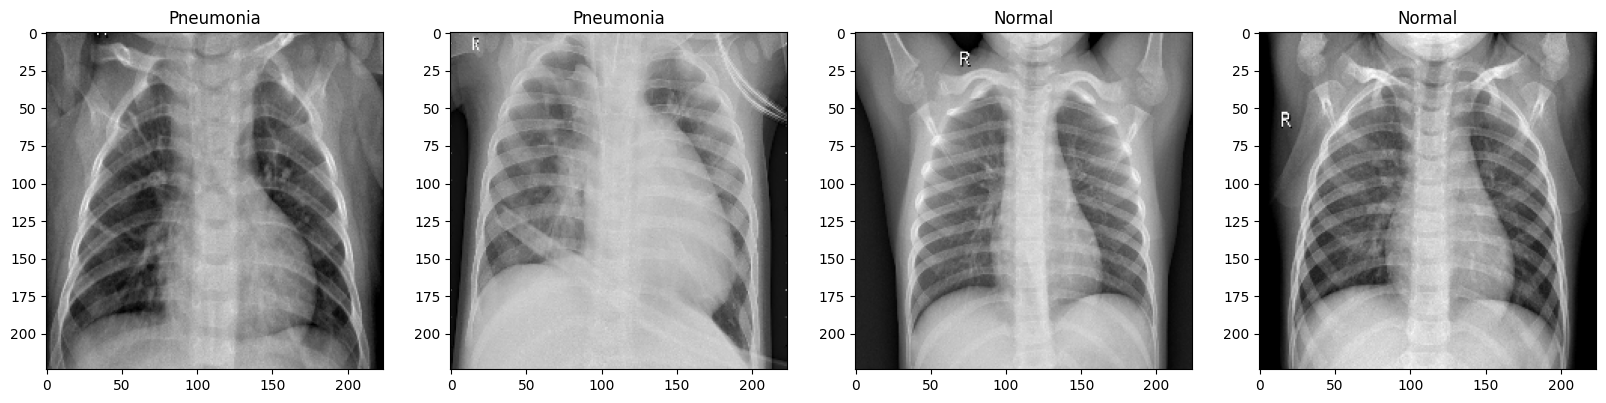

In [9]:
# Display some images from train set
# Feel free to show more image by changing the values

import matplotlib.pyplot as plt 

fig = plt.figure(figsize=(20, 5))
k=1
for i in range(4):
    a = fig.add_subplot(1, 4, k)
    if (y[i]==0):
        a.set_title('Normal')
    else:
        a.set_title('Pneumonia')
        
    plt.imshow(X[i])
    k=k+1;
    


In [10]:
# get the labels for test set

P, t = preprocess_image(test_imgs)

In [11]:
arr=t	
uniqueValues, occurCount = np.unique(arr, return_counts=True)
 
print("Unique Values : " , uniqueValues)
print("Occurrence Count : ", occurCount)

Unique Values :  [0 1]
Occurrence Count :  [278 641]


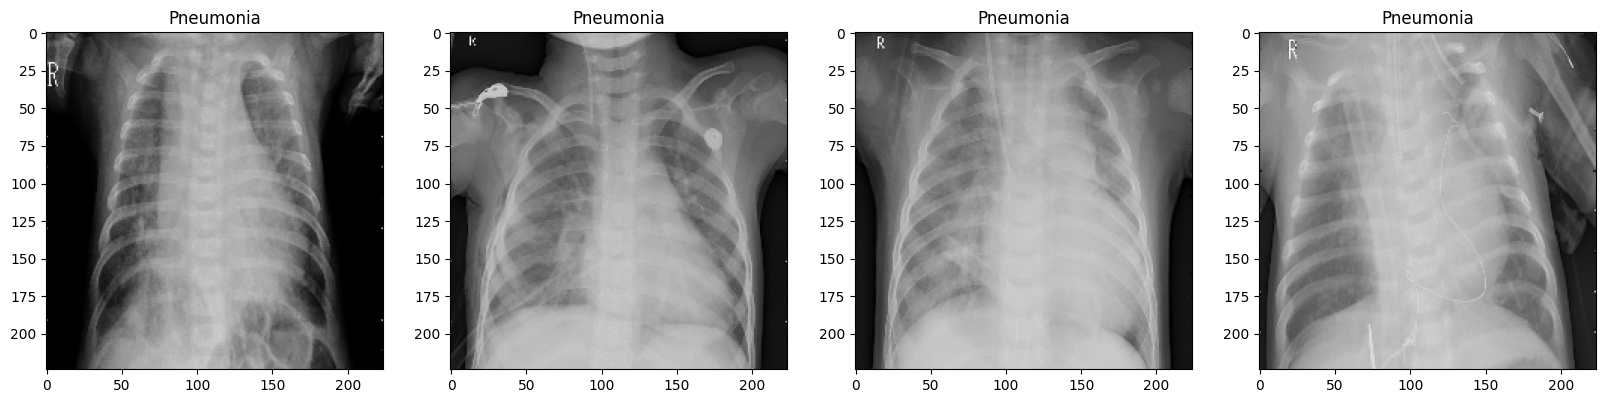

In [12]:
# now displaying some images from test set
# Feel free to show more image by changing the values

import matplotlib.pyplot as plt 

fig = plt.figure(figsize=(20, 5))
k=1
for i in range(4):
    a = fig.add_subplot(1, 4, k)
    if (t[i]==0):
        a.set_title('Normal')
    else:
        a.set_title('Pneumonia')
        
    plt.imshow(P[i])
    k=k+1;

In [13]:
# get the labels for validation set

K, m = preprocess_image(val_imgs)

In [14]:


arr=m

 
# Get a tuple of unique values & their frequency in numpy array
uniqueValues, occurCount = np.unique(arr, return_counts=True)
 
print("Unique Values : " , uniqueValues)
print("Occurrence Count : ", occurCount)

Unique Values :  [0 1]
Occurrence Count :  [ 81 214]


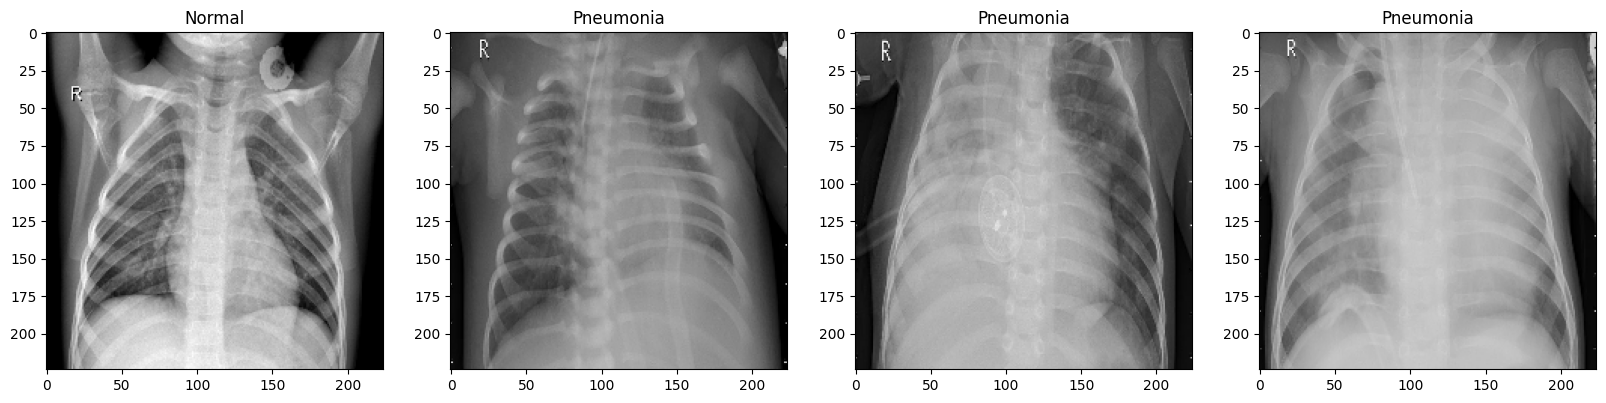

In [15]:
# now displaying some images from validation set
# Feel free to show more image by changing the values

import matplotlib.pyplot as plt 

fig = plt.figure(figsize=(20, 5))
k=1
for i in range(4):
    a = fig.add_subplot(1, 4, k)
    if (m[i]==0):
        a.set_title('Normal')
    else:
        a.set_title('Pneumonia')
        
    plt.imshow(K[i])
    k=k+1;

## Dealing with class imbalance ##

**<font size="3">We can solve the class imbalance problem with several methods. One of the simplest ways to solve the class imbalance is to simply provide a weight for each class which places more emphasis on the minority classes so CNN model can learn equally from all classes. Here, we employ sklearn compute class weight function to set weight for each class. </font>**


In [16]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np


from sklearn.utils import class_weight
import numpy as np

class_weights = {0: 4.0, 1: 1.0}

print(class_weights)

{0: 4.0, 1: 1.0}


In [17]:
import seaborn as sns
import gc

train_imgs = train_pn[:3875]+ train_normal[:1341]
del train_imgs
gc.collect()

X_train = np.array(X)
y_train = np.array(y)
X_test = np.array(P)
y_test = np.array(t)
X_val = np.array(K)
y_val = np.array(m)

print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)
print(X_val.shape)
print(y_val.shape)



(4642, 224, 224, 3)
(4642,)
(919, 224, 224, 3)
(919,)
(295, 224, 224, 3)
(295,)



<font size="6"> Training </font>




**<font size="3">We can say that training phase starts from here. We will use a batch size of 32. Batch size should be a power of 2 (4, 8, 16, 32, 64, 128, 256,....).
The batch size 32 means the model will train 32 training samples and then update its parameters once.
Batch training is faster and memory efficient.</font>**

In [18]:
# clear memory
del X
del y
gc.collect()

#get the length of the train and validation data
ntrain = len(X_train)
nval = len(X_val)

batch_size = 32

## Image Augmentation ##
**<font size="3">Lets build an input pipline for model with the augmentation technique.
We artificially increase the dataset with augmentation technique, since we are using a small dataset. 
It also helps prevent overfitting. Feel free to study various augmentation techniques in internet. </font>**

In [19]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(  rotation_range=7,
                                     width_shift_range=0.05,
                                     height_shift_range=0.05,
                                     shear_range=0.2,
                                     zoom_range=0.45,
                                     horizontal_flip=True)
                                   
val_datagen = ImageDataGenerator(zoom_range=0.45)  

In [20]:
#Create the image generators
train_generator = train_datagen.flow(X_train, y_train, batch_size=batch_size)
val_generator = val_datagen.flow(X_val, y_val, batch_size=batch_size)

In [21]:
# Set image Size
img_size =224

## Train full train set with MobileNet  ##

**<font size="3"> We don't build a convolutional neural network (CNN) architecture from scratch here. Instead, we use a pretrainted CNN architecture called MobileNet. </font>**

In [22]:
from keras import layers
from keras import models
from keras import optimizers
from keras.applications import *
from keras.layers import Dense, GlobalAveragePooling2D
from keras.preprocessing.image import img_to_array, load_img
from keras.models import Model
from keras import backend as K

# Create the base pre-trained model
# Weights should be none becuase we don't need to train with any pre-trained weights here

base_model = MobileNet(weights=None, include_top=False,input_shape=(img_size, img_size, 3)) 

x = base_model.output

# Add a global spatial average pooling layer
x = GlobalAveragePooling2D()(x)

# Add a logistic layer
predictions = Dense(1, activation="sigmoid")(x)

model = Model(inputs=base_model.input, outputs=predictions)
# Compile model
model.compile(optimizer='adam', loss = 'binary_crossentropy',
                           metrics = ['binary_accuracy', 'mae'])

In [23]:
# We can see details of  MobileNet architecure's details
# model.summary()

**<font size="3">Keep your GPU on or training time will be so high. Check your kaggle notebook's settings.**</font>

In [24]:


history = model.fit(train_generator,
                              steps_per_epoch=ntrain // batch_size,
                              epochs=15,
                              validation_data=val_generator,
                              validation_steps=nval // batch_size,
                              class_weight =class_weights,
)

c:\Users\spiri\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/15
145/145 ━━━━━━━━━━━━━━━━━━━━ 324s 2s/step - binary_accuracy: 0.7482 - loss: 0.8127 - mae: 0.2844 - val_binary_accuracy: 0.7257 - val_loss: 1.1456 - val_mae: 0.2815
Epoch 2/15
  1/145 ━━━━━━━━━━━━━━━━━━━━ 5:07 2s/step - binary_accuracy: 0.8438 - loss: 0.4489 - mae: 0.2295

c:\Users\spiri\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\trainers\epoch_iterator.py:107: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


145/145 ━━━━━━━━━━━━━━━━━━━━ 7s 35ms/step - binary_accuracy: 0.8438 - loss: 0.4489 - mae: 0.2295 - val_binary_accuracy: 0.7292 - val_loss: 1.1381 - val_mae: 0.2780
Epoch 3/15
145/145 ━━━━━━━━━━━━━━━━━━━━ 307s 2s/step - binary_accuracy: 0.8587 - loss: 0.4979 - mae: 0.1795 - val_binary_accuracy: 0.7257 - val_loss: 1.5003 - val_mae: 0.2762
Epoch 4/15
145/145 ━━━━━━━━━━━━━━━━━━━━ 6s 29ms/step - binary_accuracy: 0.9688 - loss: 0.2137 - mae: 0.0938 - val_binary_accuracy: 0.7292 - val_loss: 1.4872 - val_mae: 0.2727
Epoch 5/15
145/145 ━━━━━━━━━━━━━━━━━━━━ 280s 2s/step - binary_accuracy: 0.8710 - loss: 0.4793 - mae: 0.1668 - val_binary_accuracy: 0.7292 - val_loss: 1.7270 - val_mae: 0.2716
Epoch 6/15
145/145 ━━━━━━━━━━━━━━━━━━━━ 7s 32ms/step - binary_accuracy: 0.8750 - loss: 0.4621 - mae: 0.1937 - val_binary_accuracy: 0.7257 - val_loss: 1.7384 - val_mae: 0.2751
Epoch 7/15
145/145 ━━━━━━━━━━━━━━━━━━━━ 278s 2s/step - binary_accuracy: 0.8857 - loss: 0.4169 - mae: 0.1491 - val_binary_accuracy: 0.722

**<font size="3">Plot how validation accuracy and loss are increasing  against training accuracy and loss.</font>**

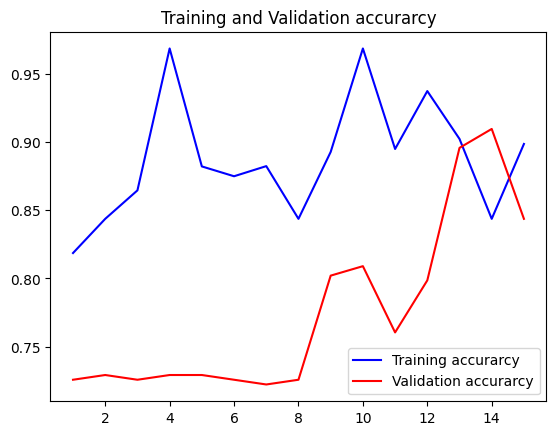

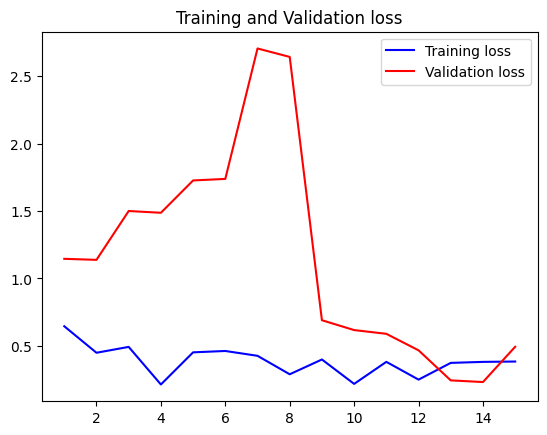

In [25]:
# Lets plot the train and val curve
# Get the details form the history object
acc = history.history['binary_accuracy']
val_acc = history.history['val_binary_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(1, len(acc) + 1)

#Train and validation accuracy
plt.plot(epochs, acc, 'b', label='Training accurarcy')
plt.plot(epochs, val_acc, 'r', label='Validation accurarcy')
plt.title('Training and Validation accurarcy')
plt.legend()

plt.figure()
#Train and validation loss
plt.plot(epochs, loss, 'b', label='Training loss')
plt.plot(epochs, val_loss, 'r', label='Validation loss')
plt.title('Training and Validation loss')
plt.legend()

plt.show()

## Estimation of classification performance / Result ##
**<font size="3">We will check our model classification ability using some evaluation matrices. It is very important to use multiple evaluation metrics to evaluate your model to ensure that the model is operating correctly and optimally. We will check our model's performance by Accuracy, Recall, Precision, F1 and AUC score. Feel free to search in google to know more about these matrices. </font>**

In [26]:
from sklearn.metrics import accuracy_score, confusion_matrix

preds = model.predict(X_test)

acc = accuracy_score(y_test, np.round(preds))*100
cm = confusion_matrix(y_test, np.round(preds))

tn, fp, fn, tp = cm.ravel()

print('CONFUSION MATRIX ------------------')
print(cm)

print('\n============TEST METRICS=============')
precision = tp/(tp+fp)*100
recall = tp/(tp+fn)*100
print('Accuracy: {}%'.format(acc))
print('Precision: {}%'.format(precision))
print('Recall: {}%'.format(recall))
print('F1-score: {}'.format(2*precision*recall/(precision+recall)))

print('\nTRAIN METRIC ----------------------')
print('Train acc: {}'.format(np.round((history.history['binary_accuracy'][-1])*100, 2)))

29/29 ━━━━━━━━━━━━━━━━━━━━ 14s 465ms/step
CONFUSION MATRIX ------------------
[[260  18]
 [193 448]]

============TEST METRICS=============
Accuracy: 77.04026115342764%
Precision: 96.13733905579399%
Recall: 69.89079563182527%
F1-score: 80.93947606142729

TRAIN METRIC ----------------------
Train acc: 89.87


<Axes: >

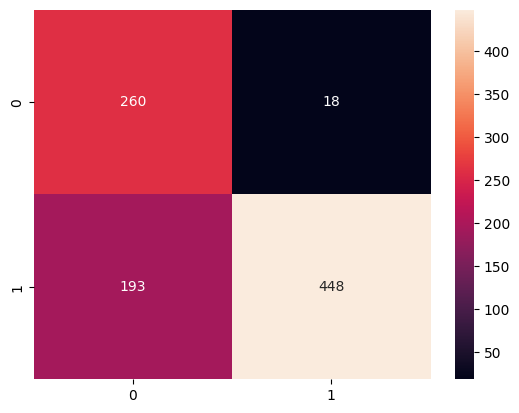

In [27]:
import seaborn as sns
sns.heatmap(cm, annot=True, fmt="d",)

**<font size="3">The ROC (receiver operating characteristic) curve indicates the diagnostic accuracy and porformance of a model.
We show the ROC curve and also calculate AUC score.</font>**

AUC Score: 0.9199429847697504


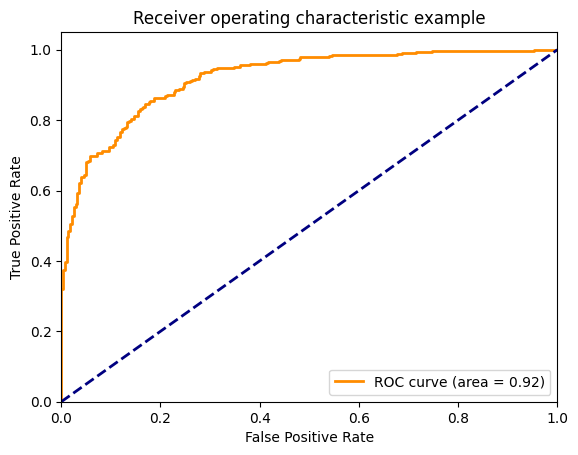

In [28]:
from sklearn.metrics import roc_curve,roc_auc_score
from sklearn.metrics import auc

fpr , tpr , thresholds = roc_curve ( y_test , preds)
auc_keras = auc(fpr, tpr)
print("AUC Score:",auc_keras)
plt.figure()
lw = 2
plt.plot(fpr, tpr, color='darkorange',
         lw=lw, label='ROC curve (area = %0.2f)' % auc_keras)
plt.plot([0, 1], [0, 1], color='navy', lw=lw, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver operating characteristic example')
plt.legend(loc="lower right")
plt.show()

In [29]:
import os
import shutil
import random
import matplotlib.pyplot as plt

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models

In [30]:
def create_subset(original_dir, subset_dir, fraction):
    if os.path.exists(subset_dir):
        shutil.rmtree(subset_dir)

    os.makedirs(subset_dir)

    for class_name in os.listdir(original_dir):
        class_path = os.path.join(original_dir, class_name)

        if not os.path.isdir(class_path):
            continue

        os.makedirs(os.path.join(subset_dir, class_name))

        images = os.listdir(class_path)
        random.shuffle(images)

        subset_size = int(len(images) * fraction)

        # ensure at least 1 image
        subset_size = max(1, subset_size)

        selected = images[:subset_size]

        for img in selected:
            shutil.copy(
                os.path.join(class_path, img),
                os.path.join(subset_dir, class_name, img)
            )

In [31]:
def create_model():
    model = models.Sequential([
        layers.Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)),
        layers.MaxPooling2D(2,2),

        layers.Conv2D(64, (3,3), activation='relu'),
        layers.MaxPooling2D(2,2),

        layers.Conv2D(128, (3,3), activation='relu'),
        layers.MaxPooling2D(2,2),

        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(2, activation='softmax')  # 👈 dataset has 2 classes
    ])

    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

In [32]:
base_dir = "C:/Users/spiri/Downloads/Chest x-ray/chest_xray"
train_dir = os.path.join(base_dir, "train")
val_dir = os.path.join(base_dir, "val")

In [33]:
fractions = [0.2, 0.4, 0.6, 0.8]
histories = {}
results = {}

for frac in fractions:
    print(f"\nTraining with {int(frac*100)}% data\n")

    subset_dir = f"subset_{int(frac*100)}"
    create_subset(train_dir, subset_dir, frac)

    train_gen = ImageDataGenerator(rescale=1./255).flow_from_directory(
        subset_dir,
        target_size=(224,224),
        batch_size=32,
        class_mode='categorical'
    )

    val_gen = ImageDataGenerator(rescale=1./255).flow_from_directory(
        val_dir,
        target_size=(224,224),
        batch_size=32,
        class_mode='categorical'
    )

    model = create_model()

    history = model.fit(
        train_gen,
        validation_data=val_gen,
        epochs=5,   # keep small for speed
        verbose=1
    )
    val_gen.reset()

    pred_probs = model.predict(val_gen)
    y_pred = np.argmax(pred_probs, axis=1)

    y_true = val_gen.classes

    from sklearn.metrics import confusion_matrix
    cm = confusion_matrix(y_true, y_pred)

    tn, fp, fn, tp = cm.ravel()

    accuracy = (tp + tn) / (tp + tn + fp + fn)
    sensitivity = tp / (tp + fn)
    specificity = tn / (tn + fp)
    f1 = (2 * tp) / (2 * tp + fp + fn)

    results[frac] = {
        "accuracy": accuracy,
        "f1_score": f1,
        "sensitivity": sensitivity,
        "specificity": specificity
    }

    histories[frac] = history


Training with 20% data

Found 1043 images belonging to 2 classes.
Found 16 images belonging to 2 classes.


c:\Users\spiri\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
c:\Users\spiri\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/5
33/33 ━━━━━━━━━━━━━━━━━━━━ 35s 1s/step - accuracy: 0.6825 - loss: 0.8572 - val_accuracy: 0.7500 - val_loss: 0.4619
Epoch 2/5
33/33 ━━━━━━━━━━━━━━━━━━━━ 24s 716ms/step - accuracy: 0.9024 - loss: 0.2585 - val_accuracy: 0.8125 - val_loss: 0.4312
Epoch 3/5
33/33 ━━━━━━━━━━━━━━━━━━━━ 26s 795ms/step - accuracy: 0.9533 - loss: 0.1498 - val_accuracy: 0.8750 - val_loss: 0.2880
Epoch 4/5
33/33 ━━━━━━━━━━━━━━━━━━━━ 24s 714ms/step - accuracy: 0.9399 - loss: 0.1417 - val_accuracy: 0.8125 - val_loss: 0.3439
Epoch 5/5
33/33 ━━━━━━━━━━━━━━━━━━━━ 24s 730ms/step - accuracy: 0.9540 - loss: 0.1175 - val_accuracy: 0.7500 - val_loss: 0.9114
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 222ms/step

Training with 40% data

Found 2086 images belonging to 2 classes.
Found 16 images belonging to 2 classes.


c:\Users\spiri\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
c:\Users\spiri\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/5
66/66 ━━━━━━━━━━━━━━━━━━━━ 66s 976ms/step - accuracy: 0.7141 - loss: 0.6703 - val_accuracy: 0.6250 - val_loss: 0.7876
Epoch 2/5
66/66 ━━━━━━━━━━━━━━━━━━━━ 47s 700ms/step - accuracy: 0.9277 - loss: 0.1771 - val_accuracy: 0.6250 - val_loss: 0.6210
Epoch 3/5
66/66 ━━━━━━━━━━━━━━━━━━━━ 43s 648ms/step - accuracy: 0.9439 - loss: 0.1373 - val_accuracy: 0.6875 - val_loss: 0.7913
Epoch 4/5
66/66 ━━━━━━━━━━━━━━━━━━━━ 44s 670ms/step - accuracy: 0.9583 - loss: 0.1129 - val_accuracy: 0.8125 - val_loss: 0.4168
Epoch 5/5
66/66 ━━━━━━━━━━━━━━━━━━━━ 47s 707ms/step - accuracy: 0.9746 - loss: 0.0777 - val_accuracy: 0.8125 - val_loss: 0.3360
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 207ms/step

Training with 60% data

Found 3129 images belonging to 2 classes.
Found 16 images belonging to 2 classes.


c:\Users\spiri\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
c:\Users\spiri\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/5
98/98 ━━━━━━━━━━━━━━━━━━━━ 87s 860ms/step - accuracy: 0.7871 - loss: 0.7450 - val_accuracy: 0.8750 - val_loss: 0.3115
Epoch 2/5
98/98 ━━━━━━━━━━━━━━━━━━━━ 66s 673ms/step - accuracy: 0.9351 - loss: 0.1564 - val_accuracy: 0.8750 - val_loss: 0.3245
Epoch 3/5
98/98 ━━━━━━━━━━━━━━━━━━━━ 65s 662ms/step - accuracy: 0.9592 - loss: 0.1131 - val_accuracy: 0.8750 - val_loss: 0.2638
Epoch 4/5
98/98 ━━━━━━━━━━━━━━━━━━━━ 66s 669ms/step - accuracy: 0.9646 - loss: 0.0948 - val_accuracy: 0.7500 - val_loss: 0.4574
Epoch 5/5
98/98 ━━━━━━━━━━━━━━━━━━━━ 66s 674ms/step - accuracy: 0.9613 - loss: 0.0961 - val_accuracy: 0.9375 - val_loss: 0.1783
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 216ms/step

Training with 80% data

Found 4172 images belonging to 2 classes.
Found 16 images belonging to 2 classes.


c:\Users\spiri\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
c:\Users\spiri\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/5
131/131 ━━━━━━━━━━━━━━━━━━━━ 115s 866ms/step - accuracy: 0.7613 - loss: 0.5114 - val_accuracy: 0.7500 - val_loss: 0.6336
Epoch 2/5
131/131 ━━━━━━━━━━━━━━━━━━━━ 91s 691ms/step - accuracy: 0.9522 - loss: 0.1304 - val_accuracy: 0.6875 - val_loss: 0.4466
Epoch 3/5
131/131 ━━━━━━━━━━━━━━━━━━━━ 94s 718ms/step - accuracy: 0.9649 - loss: 0.1163 - val_accuracy: 0.7500 - val_loss: 0.8677
Epoch 4/5
131/131 ━━━━━━━━━━━━━━━━━━━━ 90s 684ms/step - accuracy: 0.9688 - loss: 0.0881 - val_accuracy: 0.6875 - val_loss: 1.2806
Epoch 5/5
131/131 ━━━━━━━━━━━━━━━━━━━━ 85s 651ms/step - accuracy: 0.9715 - loss: 0.0704 - val_accuracy: 0.8750 - val_loss: 0.4164
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 215ms/step


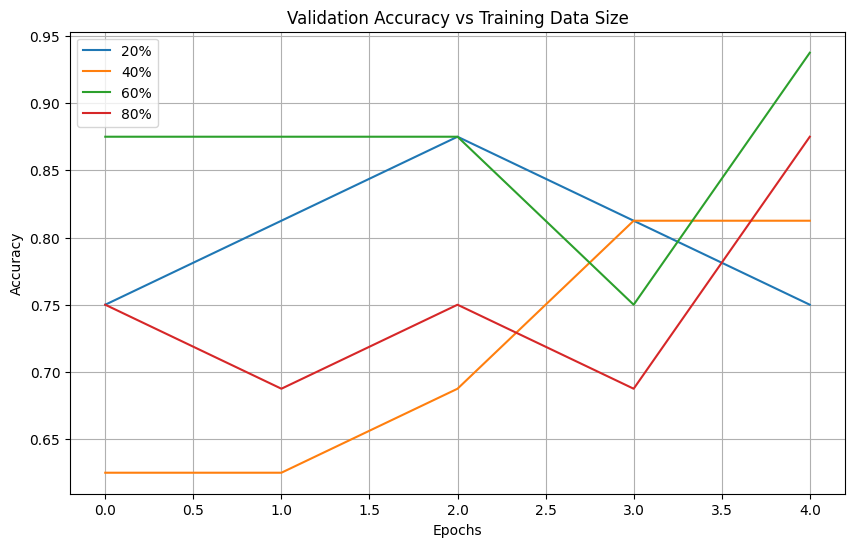

In [34]:
plt.figure(figsize=(10,6))

for frac, history in histories.items():
    plt.plot(history.history['val_accuracy'], label=f"{int(frac*100)}%")

plt.title("Validation Accuracy vs Training Data Size")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid()
plt.show()

In [35]:
for frac, res in results.items():
    print(f"\n{int(frac*100)}% DATA:")
    print(f"Accuracy     : {res['accuracy']:.4f}")
    print(f"F1-score     : {res['f1_score']:.4f}")
    print(f"Sensitivity  : {res['sensitivity']:.4f}")
    print(f"Specificity  : {res['specificity']:.4f}")


20% DATA:
Accuracy     : 0.7500
F1-score     : 0.8000
Sensitivity  : 1.0000
Specificity  : 0.5000

40% DATA:
Accuracy     : 0.4375
F1-score     : 0.5263
Sensitivity  : 0.6250
Specificity  : 0.2500

60% DATA:
Accuracy     : 0.4375
F1-score     : 0.4706
Sensitivity  : 0.5000
Specificity  : 0.3750

80% DATA:
Accuracy     : 0.5000
F1-score     : 0.5556
Sensitivity  : 0.6250
Specificity  : 0.3750
